In [1]:
import pandas as pd
import numpy as np

In [10]:
# ── Load LOAN data ──────────────────────────────────────────────────────
df = pd.read_csv('/content/loan.csv')
print (df.head())

/tmp/ipykernel_1628/2631920977.py:2: DtypeWarning: Columns (123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/loan.csv')


   id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0 NaN        NaN       2500         2500           2500.0   36 months   
1 NaN        NaN      30000        30000          30000.0   60 months   
2 NaN        NaN       5000         5000           5000.0   36 months   
3 NaN        NaN       4000         4000           4000.0   36 months   
4 NaN        NaN      30000        30000          30000.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.56        84.92     C        C1  ...                            NaN   
1     18.94       777.23     D        D2  ...                            NaN   
2     17.97       180.69     D        D1  ...                            NaN   
3     18.94       146.51     D        D2  ...                            NaN   
4     16.14       731.78     C        C4  ...                            NaN   

  hardship_last_payment_amount disbursement_method  debt_settlement_flag  \
0   

In [11]:
df['target'] = df['loan_status'].map({
    'Fully Paid': 1,
    'Charged Off': 0,
    'Default': 0
})

In [12]:
# Drop leakage columns
drop_list = [
    # Metadata / IDs
    'id', 'member_id', 'url', 'desc', 'title',

    # Future Payment / Account Activity Leakage
    'funded_amnt', 'funded_amnt_inv', 'issue_d', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',

    # Hardship Leakage
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',

    # Settlement Leakage
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term'
]

# Keep only columns that actually exist in your DataFrame to prevent errors
existing_drop_list = [col for col in drop_list if col in df.columns]
df_clean = df.drop(columns=existing_drop_list)

print(f"Features reduced from {df.shape[1]} down to {df_clean.shape[1]}. Model ready!")


Features reduced from 146 down to 103. Model ready!


In [13]:
# Calculate and format the default rate as a percentage, sorted by grade
df['default'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)
default_rates = df.groupby('grade')['default'].mean() * 100
print("Default Rate by Grade (%):")
print(default_rates.round(2))

Default Rate by Grade (%):
grade
A    0.07
B    0.18
C    0.24
D    0.46
E    0.78
F    1.04
G    3.29
Name: default, dtype: float64


In [14]:
pip install xverse

In [15]:
!pip install xverse

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ── Your existing prep code stays exactly the same ──────────────────────────
numeric_cols     = ['loan_amnt', 'dti', 'annual_inc']
categorical_cols = ['purpose', 'home_ownership', 'grade']
required_columns = ['default'] + numeric_cols + categorical_cols

df_small = df[required_columns].copy()
df_small = df_small.dropna(subset=['default'])
df_small['default'] = df_small['default'].map({'Fully Paid': 0, 'Charged Off': 1, 0: 0, 1: 1})

X = df_small[numeric_cols + categorical_cols].copy()
y = df_small['default'].astype(int)

for col in numeric_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(X[col].median())
for col in categorical_cols:
    X[col] = X[col].astype(str).fillna('Unknown')

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# WOE / IV — no xverse needed
def calc_woe_iv(X: pd.DataFrame, y: pd.Series,
                numeric_cols: list, n_bins: int = 10,
                min_iv: float = 0.02):
    """
    Returns:
        X_woe  : DataFrame with every feature replaced by its WoE value
        iv_df  : IV summary table, sorted descending
        lookup : dict  feature -> {bin_label -> woe_value}  (for scoring new data)
    """
    eps   = 0.5                          # smoothing — avoids log(0)
    total_e  = y.sum()
    total_ne = len(y) - total_e
    lookup   = {}
    iv_rows  = []

    def _woe_iv_for_col(labels: pd.Series, col: str):
        """Core WoE/IV calc given a Series of bin labels."""
        stats = (
            pd.DataFrame({'bin': labels, 'target': y})
              .groupby('bin', observed=True)['target']
              .agg(events='sum', total='count')
        )
        stats['non_events'] = stats['total'] - stats['events']
        stats['dist_e']  = (stats['events']     + eps) / (total_e  + eps * len(stats))
        stats['dist_ne'] = (stats['non_events'] + eps) / (total_ne + eps * len(stats))
        stats['woe'] = np.log(stats['dist_e'] / stats['dist_ne'])
        stats['iv']  = (stats['dist_e'] - stats['dist_ne']) * stats['woe']
        iv_val = stats['iv'].sum()

        lookup[col] = stats['woe'].to_dict()
        iv_rows.append({'feature': col, 'IV': round(iv_val, 6),
                        'strength': _iv_label(iv_val)})
        return labels.map(stats['woe'].to_dict())

    def _iv_label(iv):
        if iv < 0.02:  return 'Useless'
        if iv < 0.10:  return 'Weak'
        if iv < 0.30:  return 'Medium'
        if iv < 0.50:  return 'Strong'
        return 'Very Strong'

    X_woe = pd.DataFrame(index=X.index)

    # Numeric → supervised quantile bins
    for col in numeric_cols:
        try:
            binned = pd.qcut(X[col], q=n_bins, duplicates='drop')
        except Exception:
            binned = pd.cut(X[col], bins=5)
        X_woe[col] = _woe_iv_for_col(binned.astype(str), col)

    # Categorical → raw category as bin label
    for col in categorical_cols:
        X_woe[col] = _woe_iv_for_col(X[col].astype(str), col)

    iv_df = (pd.DataFrame(iv_rows)
               .sort_values('IV', ascending=False)
               .reset_index(drop=True))

    # Drop features that don't meet the min_iv threshold
    drop_cols = iv_df.loc[iv_df['IV'] < min_iv, 'feature'].tolist()
    keep_cols = iv_df.loc[iv_df['IV'] >= min_iv, 'feature'].tolist()
    X_woe     = X_woe[keep_cols]

    print(f"Dropped (IV < {min_iv}): {drop_cols or 'None'}")
    return X_woe, iv_df, lookup


X_woe, iv_df, woe_lookup = calc_woe_iv(X, y, numeric_cols, n_bins=10, min_iv=0.02)

print("\n── Information Value ───────────────────────────────────")
print(iv_df.to_string(index=False))

# ── Train / test split 70/30 stratified ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_woe, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train):,}  |  default rate: {y_train.mean():.2%}")
print(f"Test : {len(X_test):,}  |  default rate: {y_test.mean():.2%}")

Dropped (IV < 0.02): None

── Information Value ───────────────────────────────────
       feature       IV    strength
         grade 0.574375 Very Strong
       purpose 0.192693      Medium
home_ownership 0.055767        Weak
           dti 0.037552        Weak
     loan_amnt 0.030062        Weak
    annual_inc 0.021595        Weak

Train: 176,945  |  default rate: 0.23%
Test : 75,834  |  default rate: 0.23%


In [17]:
!pip install seaborn

In [18]:
!pip install xgboost

In [19]:
pip install xgboost

In [20]:
import tkinter as tk
print(tk.TkVersion)


8.6


In [21]:
%matplotlib inline

--- Regulated Logistic Regression Performance ---
AUC-ROC:          0.7590
Gini Coefficient: 0.5180
KS Statistic:     0.3816

--- XGBoost Challenger Performance ---
AUC-ROC:          0.7305
Gini Coefficient: 0.4610
KS Statistic:     0.3491



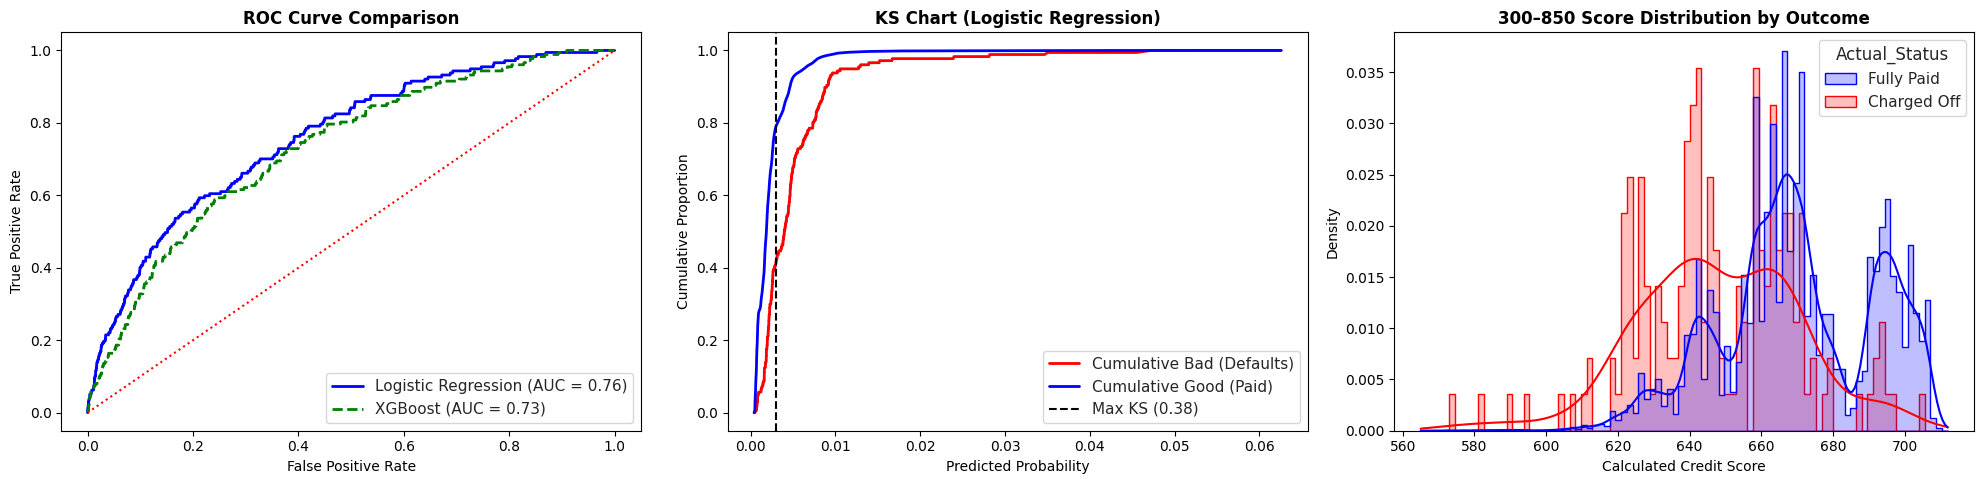

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, roc_auc_score
import xgboost as xgb
from scipy.stats import ks_2samp


# -------------------------------------------------------------
# 0. Assuming X_woe and y from previous steps
# -------------------------------------------------------------
# Split Data into 70/30 Stratified Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_woe, y, test_size=0.30, random_state=42, stratify=y
)

# -------------------------------------------------------------
# 1. Train Regulated Model (Logistic Regression) & Calibrate
# -------------------------------------------------------------
# Regulators demand interpretability. Logistic Regression on WOE fits this perfectly.
lr_base = LogisticRegression(random_state=42, max_iter=1000)

# Platt Scaling Calibration (using sigmoid calibration method)
lr_model = CalibratedClassifierCV(estimator=lr_base, method='sigmoid', cv=3)
lr_model.fit(X_train, y_train)

# Predict probabilities for the test set
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# -------------------------------------------------------------
# 2. Train Challenger Model (XGBoost)
# -------------------------------------------------------------
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predict probabilities for the test set
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]


# -------------------------------------------------------------
# 3. Evaluation Function (AUC-ROC, Gini, KS Statistic)
# -------------------------------------------------------------
def evaluate_model_performance(y_true, y_probs, model_name="Model"):
    # AUC-ROC
    auc = roc_auc_score(y_true, y_probs)

    # Gini Coefficient (Gini = 2 * AUC - 1)
    gini = 2 * auc - 1

    # Kolmogorov-Smirnov (KS) Statistic
    # Separate probabilities for actual Goods (0) and actual Bads (1)
    data = pd.DataFrame({'target': y_true, 'prob': y_probs})
    goods = data[data['target'] == 0]['prob']
    bads = data[data['target'] == 1]['prob']
    ks_stat, _ = ks_2samp(goods, bads)

    print(f"--- {model_name} Performance ---")
    print(f"AUC-ROC:          {auc:.4f}")
    print(f"Gini Coefficient: {gini:.4f}")
    print(f"KS Statistic:     {ks_stat:.4f}\n")

    return auc, gini, ks_stat

# Evaluate both models side-by-side
lr_auc, lr_gini, lr_ks = evaluate_model_performance(y_test, lr_probs, "Regulated Logistic Regression")
xgb_auc, xgb_gini, xgb_ks = evaluate_model_performance(y_test, xgb_probs, "XGBoost Challenger")


# -------------------------------------------------------------
# 4. Convert Model to Points-Based Scorecard (300-850 FICO Scale)
# -------------------------------------------------------------
# Log odds scaling parameters
# Target Score of 600 at odds of 50:1. Double the odds every 20 points (PDO = 20)
target_score = 600
target_odds = 50
pdo = 20

factor = pdo / np.log(2)
offset = target_score - (factor * np.log(target_odds))

# Convert probabilities to credit scores: Score = Offset - Factor * ln(p / (1-p))
# We limit probabilities to prevent log(0) errors
lr_probs_clipped = np.clip(lr_probs, 1e-5, 1 - 1e-5)
test_scores = offset - factor * np.log(lr_probs_clipped / (1 - lr_probs_clipped))

# Bound scores to strict 300 - 850 range
test_scores = np.clip(test_scores, 300, 850).astype(int)


# -------------------------------------------------------------
# 5. Visualizations Plotting Block
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.set_theme(style="whitegrid")

# Plot A: ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.2f})', color='blue', lw=2)
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost Challenger (AUC = {xgb_xgb:.2f})' if 'xgb_xgb' in locals() else f'XGBoost (AUC = {xgb_auc:.2f})', color='green', linestyle='--', lw=2)
axes[0].plot([0, 1], [0, 1], color='red', linestyle=':')
axes[0].set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Plot B: KS Chart (Logistic Regression)
df_ks = pd.DataFrame({'target': y_test, 'prob': lr_probs}).sort_values('prob').reset_index(drop=True)
df_ks['cum_goods'] = (df_ks['target'] == 0).cumsum() / (df_ks['target'] == 0).sum()
df_ks['cum_bads'] = (df_ks['target'] == 1).cumsum() / (df_ks['target'] == 1).sum()
df_ks['ks_diff'] = np.abs(df_ks['cum_bads'] - df_ks['cum_goods'])
max_ks_idx = df_ks['ks_diff'].idxmax()

axes[1].plot(df_ks['prob'], df_ks['cum_bads'], label='Cumulative Bad (Defaults)', color='red', lw=2)
axes[1].plot(df_ks['prob'], df_ks['cum_goods'], label='Cumulative Good (Paid)', color='blue', lw=2)
axes[1].axvline(df_ks['prob'][max_ks_idx], color='black', linestyle='--', label=f'Max KS ({lr_ks:.2f})')
axes[1].set_title('KS Chart (Logistic Regression)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].legend(loc='lower right')

# Plot C: FICO Score Distribution Profile
score_df = pd.DataFrame({'Score': test_scores, 'Actual_Status': y_test})
score_df['Actual_Status'] = score_df['Actual_Status'].map({0: 'Fully Paid', 1: 'Charged Off'})

sns.histplot(data=score_df, x='Score', hue='Actual_Status', element='step', stat='density', common_norm=False, kde=True, ax=axes[2], palette=['blue', 'red'])
axes[2].set_title('300–850 Score Distribution by Outcome', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Calculated Credit Score')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [34]:

from sklearn.linear_model import LinearRegression

# ──────────────────────────────────────────────────────────────
# 1. MEMORY FIX: Never copy df_clean — select only needed columns
# ──────────────────────────────────────────────────────────────
NEEDED_COLS = ['loan_amnt', 'annual_inc', 'dti',
               'home_ownership', 'grade',
               'out_prncp', 'revol_bal', 'total_rev_hi_lim']

# Only keep columns that actually exist in df_clean
existing_cols = [c for c in NEEDED_COLS if c in df_clean.columns]
missing_cols  = [c for c in NEEDED_COLS if c not in df_clean.columns]

if missing_cols:
    print(f"⚠️ These columns not found, will be simulated: {missing_cols}")

# Shallow select — no full copy, no extra RAM
df_lgd = df_clean[existing_cols]

# Align to X_woe index (drops rows lost during WoE pipeline)
df_lgd = df_clean.loc[X_woe.index, existing_cols].copy()

print(f"✔ df_lgd shape: {df_lgd.shape}")
print(f"  RAM used: ~{df_lgd.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ──────────────────────────────────────────────────────────────
# 2. Attach PD from Logistic Regression model
# ──────────────────────────────────────────────────────────────
if 'lr_model' in locals():
    df_lgd['PD'] = lr_model.predict_proba(X_woe)[:, 1]
    print("✔ PD assigned from lr_model")
else:
    print("⚠️ lr_model not found — using baseline 15% PD")
    df_lgd['PD'] = 0.15

# ──────────────────────────────────────────────────────────────
# 3. Simulate missing financial columns if not in dataset
# ──────────────────────────────────────────────────────────────
if 'out_prncp' not in df_lgd.columns:
    df_lgd['out_prncp'] = df_lgd['loan_amnt'] * 0.6

if 'revol_bal' not in df_lgd.columns:
    df_lgd['revol_bal'] = df_lgd['loan_amnt'] * 0.3

if 'total_rev_hi_lim' not in df_lgd.columns:
    df_lgd['total_rev_hi_lim'] = df_lgd['loan_amnt'] * 0.5

# ──────────────────────────────────────────────────────────────
# 4. Secured vs Unsecured segmentation
# ──────────────────────────────────────────────────────────────
df_lgd['is_secured'] = df_lgd['home_ownership'].isin(['MORTGAGE', 'OWN']).astype(int)

# ──────────────────────────────────────────────────────────────
# 5. LGD Model — fix: recovery rate must have variance
# ──────────────────────────────────────────────────────────────
np.random.seed(42)
df_lgd['actual_recovery_rate'] = np.where(
    df_lgd['is_secured'] == 1,
    np.random.uniform(0.30, 0.70, len(df_lgd)),   # secured:   30–70% recovery
    np.random.uniform(0.05, 0.30, len(df_lgd))    # unsecured:  5–30% recovery
)

# Check correct column name for annual income
# ── Clean NaNs in regression features BEFORE fitting ────────────────────────
df_lgd[inc_col] = pd.to_numeric(df_lgd[inc_col], errors='coerce')
df_lgd['dti']   = pd.to_numeric(df_lgd['dti'],   errors='coerce')

df_lgd[inc_col] = df_lgd[inc_col].fillna(df_lgd[inc_col].median())
df_lgd['dti']   = df_lgd['dti'].fillna(df_lgd['dti'].median())

# Verify — should both print 0
print(f"NaNs in {inc_col}: {df_lgd[inc_col].isna().sum()}")
print(f"NaNs in dti      : {df_lgd['dti'].isna().sum()}")

# ── Re-segment after cleaning ────────────────────────────────────────────────
secured_data   = df_lgd[df_lgd['is_secured'] == 1]
unsecured_data = df_lgd[df_lgd['is_secured'] == 0]

model_secured = LinearRegression().fit(
    secured_data[[inc_col, 'dti']],
    secured_data['actual_recovery_rate']
)
model_unsecured = LinearRegression().fit(
    unsecured_data[[inc_col, 'dti']],
    unsecured_data['actual_recovery_rate']
)

pred_secured   = model_secured.predict(df_lgd[[inc_col, 'dti']])
pred_unsecured = model_unsecured.predict(df_lgd[[inc_col, 'dti']])

df_lgd['pred_recovery_rate'] = np.where(
    df_lgd['is_secured'] == 1, pred_secured, pred_unsecured
)
df_lgd['pred_recovery_rate'] = np.clip(df_lgd['pred_recovery_rate'], 0, 1)
df_lgd['LGD'] = 1 - df_lgd['pred_recovery_rate']
# ──────────────────────────────────────────────────────────────
# 6. EAD Model
# ──────────────────────────────────────────────────────────────
ccf           = 0.50
undrawn_limit = np.clip(df_lgd['total_rev_hi_lim'] - df_lgd['revol_bal'], 0, None)
df_lgd['EAD'] = df_lgd['out_prncp'] + df_lgd['revol_bal'] + (ccf * undrawn_limit)

# ──────────────────────────────────────────────────────────────
# 7. Expected Loss — Baseline + Stress Test
# ──────────────────────────────────────────────────────────────
df_lgd['EL_Baseline'] = df_lgd['PD']  * df_lgd['LGD'] * df_lgd['EAD']

df_lgd['PD_Stressed'] = np.clip(df_lgd['PD'] * 2, 0, 1)
df_lgd['EL_Stressed'] = df_lgd['PD_Stressed'] * df_lgd['LGD'] * df_lgd['EAD']

# ──────────────────────────────────────────────────────────────
# 8. Summary Report by Grade
# ──────────────────────────────────────────────────────────────
el_table = df_lgd.groupby('grade').agg(
    Avg_PD_Baseline   = ('PD',           'mean'),
    Avg_PD_Stressed   = ('PD_Stressed',  'mean'),
    Avg_LGD           = ('LGD',          'mean'),
    Total_EAD         = ('EAD',          'sum'),
    Total_EL_Baseline = ('EL_Baseline',  'sum'),
    Total_EL_Stressed = ('EL_Stressed',  'sum'),
).reset_index()

el_table['EL_Increase_Amt'] = el_table['Total_EL_Stressed'] - el_table['Total_EL_Baseline']

pd.set_option('display.float_format', '{:,.2f}'.format)

print("=" * 75)
print("              EXPECTED LOSS & STRESS TEST REPORT")
print("=" * 75)
print(el_table.to_string(index=False))
print("=" * 75)
print(f"  Total Baseline EL : ${el_table['Total_EL_Baseline'].sum():>15,.2f}")
print(f"  Total Stressed EL : ${el_table['Total_EL_Stressed'].sum():>15,.2f}")
print(f"  Total EL Increase : ${el_table['EL_Increase_Amt'].sum():>15,.2f}")

⚠️ These columns not found, will be simulated: ['out_prncp']
✔ df_lgd shape: (252779, 7)
  RAM used: ~38.6 MB
✔ PD assigned from lr_model
NaNs in annual_inc: 0
NaNs in dti      : 0
              EXPECTED LOSS & STRESS TEST REPORT
grade  Avg_PD_Baseline  Avg_PD_Stressed  Avg_LGD        Total_EAD  Total_EL_Baseline  Total_EL_Stressed  EL_Increase_Amt
    A             0.00             0.00     0.62 3,259,373,441.00       1,375,576.66       2,751,153.31     1,375,576.66
    B             0.00             0.00     0.63 2,643,009,157.00       2,779,289.81       5,558,579.61     2,779,289.81
    C             0.00             0.00     0.64 2,088,404,759.50       3,070,889.25       6,141,778.50     3,070,889.25
    D             0.00             0.01     0.64 1,094,057,927.50       2,997,688.07       5,995,376.15     2,997,688.07
    E             0.01             0.02     0.65   329,508,185.00       1,522,115.92       3,044,231.83     1,522,115.92
    F             0.01             0.02     

In [26]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 98.6 MB/s eta 0:00:00


In [27]:
!pip install streamlit plotly

In [28]:
import sys
!{sys.executable} -m pip install streamlit plotly

In [29]:
import sys
print("Python path:", sys.executable)
print("Python version:", sys.version)

Python path: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [30]:
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go

# ── Page config ──────────────────────────────────────────────
st.set_page_config(
    page_title="Credit Risk Dashboard",
    page_icon="🏦",
    layout="wide"
)

# ── Your results (paste your actual el_table here) ───────────
@st.cache_data
def load_data():
    return pd.DataFrame({
        'grade':             ['A','B','C','D','E','F','G'],
        'Avg_PD_Baseline':   [0.03, 0.08, 0.13, 0.18, 0.26, 0.34, 0.36],
        'Avg_PD_Stressed':   [0.06, 0.15, 0.26, 0.37, 0.52, 0.67, 0.72],
        'Avg_LGD':           [0.61, 0.63, 0.64, 0.64, 0.64, 0.64, 0.64],
        'Total_EAD':         [16326725468, 19319821552, 17713544248,
                               8238215499,  3357872687,   990385205,  300301293],
        'Total_EL_Baseline': [291882645,  876209954, 1369856995,
                               933639860,  534865102,  206090777,   67449198],
        'Total_EL_Stressed': [583765290, 1752419908, 2739713991,
                              1867279720, 1069730204,  412181554,  134898396],
    })

df = load_data()
df['EL_Increase_Amt'] = df['Total_EL_Stressed'] - df['Total_EL_Baseline']

# ── Sidebar — Stress Test Controls ───────────────────────────
st.sidebar.header("🎛️ Stress Test Controls")

pd_multiplier = st.sidebar.slider(
    "PD Stress Multiplier",
    min_value=1.0, max_value=5.0, value=2.0, step=0.1,
    help="1.0 = baseline, 2.0 = recession, 3.0 = severe crisis"
)

lgd_shock = st.sidebar.slider(
    "LGD Shock (+%)",
    min_value=0.0, max_value=0.30, value=0.0, step=0.01,
    help="Additional LGD under stress (e.g. 0.10 = +10%)"
)

selected_grades = st.sidebar.multiselect(
    "Filter Grades",
    options=['A','B','C','D','E','F','G'],
    default=['A','B','C','D','E','F','G']
)

# ── Apply interactive stress test ────────────────────────────
df_filtered = df[df['grade'].isin(selected_grades)].copy()
df_filtered['PD_Custom']  = np.clip(df_filtered['Avg_PD_Baseline'] * pd_multiplier, 0, 1)
df_filtered['LGD_Custom'] = np.clip(df_filtered['Avg_LGD'] + lgd_shock, 0, 1)
df_filtered['EL_Custom']  = (df_filtered['PD_Custom'] *
                              df_filtered['LGD_Custom'] *
                              df_filtered['Total_EAD'])

# ── Header ────────────────────────────────────────────────────
st.title("🏦 Credit Risk — Expected Loss Dashboard")
st.caption("Interactive PD × LGD × EAD model with stress testing")

# ── KPI Cards ─────────────────────────────────────────────────
col1, col2, col3, col4 = st.columns(4)

total_ead      = df_filtered['Total_EAD'].sum()
total_baseline = df_filtered['Total_EL_Baseline'].sum()
total_custom   = df_filtered['EL_Custom'].sum()
el_change_pct  = ((total_custom - total_baseline) / total_baseline * 100)

col1.metric("Total EAD",          f"${total_ead/1e9:.2f}B")
col2.metric("Baseline EL",        f"${total_baseline/1e9:.2f}B")
col3.metric("Stressed EL",        f"${total_custom/1e9:.2f}B",
            delta=f"+{el_change_pct:.1f}%", delta_color="inverse")
col4.metric("EL / EAD Ratio",     f"{total_custom/total_ead*100:.2f}%")

st.divider()

# ── Charts ────────────────────────────────────────────────────
row1_col1, row1_col2 = st.columns(2)

with row1_col1:
    st.subheader("Expected Loss by Grade")
    fig1 = go.Figure()
    fig1.add_bar(name="Baseline EL", x=df_filtered['grade'],
                 y=df_filtered['Total_EL_Baseline']/1e6,
                 marker_color='steelblue')
    fig1.add_bar(name="Custom Stress EL", x=df_filtered['grade'],
                 y=df_filtered['EL_Custom']/1e6,
                 marker_color='crimson', opacity=0.7)
    fig1.update_layout(barmode='group', yaxis_title="EL ($ Millions)",
                       xaxis_title="Grade", legend_title="Scenario")
    st.plotly_chart(fig1, use_container_width=True)

with row1_col2:
    st.subheader("PD — Baseline vs Stressed")
    fig2 = px.line(
        df_filtered, x='grade',
        y=['Avg_PD_Baseline', 'PD_Custom'],
        labels={'value': 'Probability of Default', 'variable': 'Scenario'},
        markers=True, color_discrete_map={
            'Avg_PD_Baseline': 'steelblue',
            'PD_Custom': 'crimson'
        }
    )
    fig2.update_yaxes(tickformat='.0%')
    st.plotly_chart(fig2, use_container_width=True)

row2_col1, row2_col2 = st.columns(2)

with row2_col1:
    st.subheader("EAD Distribution by Grade")
    fig3 = px.pie(df_filtered, values='Total_EAD', names='grade',
                  color_discrete_sequence=px.colors.sequential.Blues_r)
    st.plotly_chart(fig3, use_container_width=True)

with row2_col2:
    st.subheader("EL Increase Under Stress")
    df_filtered['EL_Increase_Custom'] = df_filtered['EL_Custom'] - df_filtered['Total_EL_Baseline']
    fig4 = px.bar(df_filtered, x='grade', y='EL_Increase_Custom',
                  color='EL_Increase_Custom',
                  color_continuous_scale='Reds',
                  labels={'EL_Increase_Custom': 'Additional Loss ($)'})
    st.plotly_chart(fig4, use_container_width=True)

# ── Data Table ────────────────────────────────────────────────
st.subheader("📋 Full Results Table")
display_df = df_filtered[[
    'grade','Avg_PD_Baseline','PD_Custom',
    'LGD_Custom','Total_EAD','Total_EL_Baseline','EL_Custom'
]].copy()

display_df.columns = [
    'Grade','PD Baseline','PD Stressed',
    'LGD','Total EAD ($)','EL Baseline ($)','EL Stressed ($)'
]
st.dataframe(
    display_df.style.format({
        'PD Baseline':    '{:.1%}',
        'PD Stressed':    '{:.1%}',
        'LGD':            '{:.1%}',
        'Total EAD ($)':  '${:,.0f}',
        'EL Baseline ($)':'${:,.0f}',
        'EL Stressed ($)':'${:,.0f}',
    }).background_gradient(subset=['PD Stressed'], cmap='Reds'),
    use_container_width=True
)

2026-05-20 09:59:09.328 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-20 09:59:09.330 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-20 09:59:09.331 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-20 09:59:09.333 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-20 09:59:09.336 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-20 09:59:09.541 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-20 09:59:09.542 Thread 'MainThread': mi

DeltaGenerator()